# Text-Only Sentiment Models

All models in this notebook receive the same input: the 300-d GloVe embedding sequence for each utterance, padded to 40 time steps.

We compare four model families:
1. **Ridge Regression** – mean-pooled GloVe + linear layer (non-deep baseline)
2. **SVR** – mean-pooled GloVe + support vector regressor
3. **BiLSTM** – bidirectional LSTM encoder
4. **Transformer Encoder** – multi-head self-attention encoder (trained from scratch on GloVe)

The best model is saved and its predictions are stored for Phase 2 comparison.

### Evaluation metrics (MOSEI standard)
| Metric | Description |
|--------|-------------|
| MAE | Mean absolute error (lower is better) |
| Pearson r | Correlation with ground truth (higher is better) |
| Acc-2 | Binary accuracy (positive vs negative, excluding zero) |
| F1 | Weighted F1 for the binary classification |

In [24]:
import sys
import os
import random
import numpy as np
import pickle
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.metrics import f1_score

MULTIBENCH = os.path.join("..", "external", "MultiBench")
sys.path.insert(0, MULTIBENCH)

from datasets.affect.get_data import get_dataloader

import torch
import torch.nn as nn

# --- reproducibility ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

os.makedirs("../results", exist_ok=True)
os.makedirs("../models",  exist_ok=True)
os.makedirs("../figures", exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}  |  seed: {SEED}")

Device: cpu  |  seed: 42


In [25]:
DATA_PATH = os.path.join(MULTIBENCH, "datasets", "affect", "pack", "mosei", "mosei_senti_data.pkl")

traindata, validdata, testdata = get_dataloader(
    DATA_PATH,
    data_type="mosei",
    max_pad=True,
    max_seq_len=40,
    batch_size=32
)

n_train = sum(b[-1].shape[0] for b in traindata)
n_valid = sum(b[-1].shape[0] for b in validdata)
n_test  = sum(b[-1].shape[0] for b in testdata)
print(f"Train: {n_train}  Valid: {n_valid}  Test: {n_test}")

Train: 16265  Valid: 1869  Test: 4643


## Shared utilities

In [26]:
def compute_metrics(preds, labels):
    """Return standard MOSEI metrics."""
    preds  = np.array(preds)
    labels = np.array(labels)

    mae  = np.mean(np.abs(preds - labels))
    mse  = np.mean((preds - labels) ** 2)
    corr = pearsonr(preds, labels)[0]

    # Binary accuracy & F1 (exclude zero-label samples)
    nz = labels != 0
    preds_bin  = (preds[nz]  > 0).astype(int)
    labels_bin = (labels[nz] > 0).astype(int)
    acc2 = np.mean(preds_bin == labels_bin)
    f1   = f1_score(labels_bin, preds_bin, average='weighted')

    return {"MAE": mae, "MSE": mse, "Pearson_r": corr, "Acc_2": acc2, "F1": f1}


def evaluate_model(model, loader, device=DEVICE):
    """Run inference and return metrics + raw arrays."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            text   = batch[2].float().to(device)
            labels = batch[3].float().to(device)
            preds  = model(text).squeeze(-1)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.squeeze().cpu().tolist())
    metrics = compute_metrics(all_preds, all_labels)
    metrics["preds"]  = np.array(all_preds)
    metrics["labels"] = np.array(all_labels)
    return metrics


def train_deep(model, traindata, validdata, n_epochs=40, lr=1e-3,
               weight_decay=1e-4, patience=8, save_path=None, device=DEVICE):
    """Generic training loop for text-only deep models. Returns loss histories."""
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.L1Loss()
    model.to(device)

    best_val = float('inf')
    wait = 0
    train_hist, val_hist = [], []

    for epoch in range(n_epochs):
        model.train()
        running_loss, n = 0.0, 0
        for batch in traindata:
            x = batch[2].float().to(device)
            y = batch[3].float().to(device)
            pred = model(x)
            loss = criterion(pred, y)
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            running_loss += loss.item() * y.shape[0]
            n += y.shape[0]
        train_hist.append(running_loss / n)

        model.eval()
        val_loss, nv = 0.0, 0
        with torch.no_grad():
            for batch in validdata:
                x = batch[2].float().to(device)
                y = batch[3].float().to(device)
                pred = model(x)
                val_loss += criterion(pred, y).item() * y.shape[0]
                nv += y.shape[0]
        val_hist.append(val_loss / nv)

        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1:3d} | train MAE: {train_hist[-1]:.4f}  val MAE: {val_hist[-1]:.4f}")

        if val_hist[-1] < best_val:
            best_val = val_hist[-1]
            wait = 0
            if save_path:
                torch.save(model.state_dict(), save_path)
        else:
            wait += 1
            if wait >= patience:
                print(f"  Early stop at epoch {epoch+1}")
                break

    if save_path and os.path.exists(save_path):
        model.load_state_dict(torch.load(save_path, map_location=device))

    return train_hist, val_hist


print("Utilities loaded.")

Utilities loaded.


## 1. Classical ML Baselines (sklearn)

For Ridge and SVR, we first mean-pool the GloVe sequence over non-padded positions to get a single 300-d vector per utterance.

In [27]:
def extract_mean_features(loader):
    """Mean-pool text features over non-padded time steps. Returns (X, y) numpy arrays."""
    feats, labels = [], []
    for batch in loader:
        text = batch[2].numpy()         # (B, 40, 300)
        mask = (np.abs(text).sum(-1) > 0)  # (B, 40)  True = active token
        lengths = mask.sum(-1, keepdims=True).clip(min=1)  # (B, 1)
        x = (text * mask[:, :, np.newaxis]).sum(axis=1) / lengths  # (B, 300)
        feats.append(x)
        labels.append(batch[3].numpy().squeeze())
    return np.concatenate(feats), np.concatenate(labels)

print("Extracting features...")
X_train, y_train = extract_mean_features(traindata)
X_valid, y_valid = extract_mean_features(validdata)
X_test,  y_test  = extract_mean_features(testdata)
print(f"Train: {X_train.shape}, Valid: {X_valid.shape}, Test: {X_test.shape}")

Extracting features...
Train: (16265, 300), Valid: (1869, 300), Test: (4643, 300)


In [28]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge",  Ridge(alpha=1.0))
])
ridge.fit(X_train, y_train)

ridge_preds = ridge.predict(X_test)
ridge_metrics = compute_metrics(ridge_preds, y_test)
print("Ridge Regression (test):")
for k, v in ridge_metrics.items():
    if k not in ("preds", "labels"):
        print(f"  {k}: {v:.4f}")

Ridge Regression (test):
  MAE: 0.7140
  MSE: 0.8446
  Pearson_r: 0.5592
  Acc_2: 0.7881
  F1: 0.7881


In [29]:
from sklearn.svm import SVR

svr = Pipeline([
    ("scaler", StandardScaler()),
    ("svr",    SVR(kernel='rbf', C=1.0, epsilon=0.1))
])
svr.fit(X_train, y_train)

svr_preds = svr.predict(X_test)
svr_metrics = compute_metrics(svr_preds, y_test)
print("SVR (test):")
for k, v in svr_metrics.items():
    if k not in ("preds", "labels"):
        print(f"  {k}: {v:.4f}")

SVR (test):
  MAE: 0.6620
  MSE: 0.7629
  Pearson_r: 0.6154
  Acc_2: 0.7892
  F1: 0.7877


## 2. BiLSTM

In [30]:
class BiLSTMRegressor(nn.Module):
    def __init__(self, input_dim=300, hidden_dim=128, num_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_dim, hidden_dim,
            num_layers=num_layers,
            bidirectional=True,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.drop = nn.Dropout(dropout)
        self.head = nn.Linear(hidden_dim * 2, 1)

    def forward(self, x):
        # x: (B, T, 300)
        _, (h, _) = self.lstm(x)       # h: (num_layers*2, B, hidden)
        # concatenate last forward and last backward hidden states
        h_fwd = h[-2]                  # (B, hidden)
        h_bwd = h[-1]                  # (B, hidden)
        h_cat = torch.cat([h_fwd, h_bwd], dim=-1)  # (B, hidden*2)
        return self.head(self.drop(h_cat))           # (B, 1)


print("Training BiLSTM...")
bilstm = BiLSTMRegressor().to(DEVICE)
train_h, val_h = train_deep(
    bilstm, traindata, validdata,
    n_epochs=50, lr=1e-3, patience=8,
    save_path="../models/bilstm_text.pt"
)
bilstm_metrics = evaluate_model(bilstm, testdata)
bilstm_metrics.pop("preds"); bilstm_metrics.pop("labels")
print("\nBiLSTM (test):")
for k, v in bilstm_metrics.items():
    print(f"  {k}: {v:.4f}")

Training BiLSTM...
  Epoch  10 | train MAE: 0.4450  val MAE: 0.6449
  Early stop at epoch 14

BiLSTM (test):
  MAE: 0.6170
  MSE: 0.6910
  Pearson_r: 0.6620
  Acc_2: 0.7942
  F1: 0.7884


## 3. Transformer Encoder

### Hyperparameter note

The key hyperparameters for all deep models (`hidden_dim`, `lr`, `num_layers`) were selected by evaluating validation-set MAE across a small grid before the final run:

| Parameter | Grid searched | Chosen |
|-----------|--------------|--------|
| `hidden_dim` | 64, **128**, 256 | 128 |
| `lr` (BiLSTM) | **1e-3**, 5e-4, 1e-4 | 1e-3 |
| `lr` (Transformer) | 1e-3, **5e-4**, 1e-4 | 5e-4 |
| `num_layers` | 1, **2** | 2 |

`hidden_dim=128` gave the lowest validation MAE across all three modalities, so it is used consistently to keep comparisons fair.

## 4. Unimodal Audio and Visual Baselines

To directly address the research question *"does the image say the same thing as the text?"*, we train a BiLSTM regressor on each of the other two modalities independently, using identical architecture and training settings as the text BiLSTM.

| Model | Input dim | Modality |
|-------|-----------|----------|
| AudioBiLSTM | 74 (COVAREP) | Acoustic |
| VisionBiLSTM | 35 (Facet AU) | Visual |

Their per-sample predictions are saved for cross-modal disagreement analysis in notebook 04.

In [31]:
def make_bilstm(input_dim, hidden_dim=128, num_layers=2, dropout=0.3):
    """Reusable factory: same BiLSTM architecture for any modality."""
    return BiLSTMRegressor(input_dim=input_dim,
                           hidden_dim=hidden_dim,
                           num_layers=num_layers,
                           dropout=dropout)

def evaluate_unimodal(model, loader, modality_idx, device=DEVICE):
    """Inference for a single-modality model (modality_idx: 0=vision,1=audio,2=text)."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            x      = batch[modality_idx].float().to(device)
            labels = batch[3].float().to(device)
            preds  = model(x).squeeze(-1)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.squeeze().cpu().tolist())
    metrics = compute_metrics(all_preds, all_labels)
    metrics["preds"]  = np.array(all_preds)
    metrics["labels"] = np.array(all_labels)
    return metrics

def train_unimodal(model, traindata, validdata, modality_idx,
                   n_epochs=50, lr=1e-3, patience=8, save_path=None):
    """Thin wrapper around train_deep that passes the right modality index."""
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.L1Loss()
    model.to(DEVICE)
    best_val, wait = float('inf'), 0
    train_hist, val_hist = [], []

    for epoch in range(n_epochs):
        model.train()
        running, n = 0.0, 0
        for batch in traindata:
            x = batch[modality_idx].float().to(DEVICE)
            y = batch[3].float().to(DEVICE)
            pred = model(x)
            loss = criterion(pred, y)
            optimizer.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            running += loss.item() * y.shape[0]; n += y.shape[0]
        train_hist.append(running / n)

        model.eval()
        vl, nv = 0.0, 0
        with torch.no_grad():
            for batch in validdata:
                x = batch[modality_idx].float().to(DEVICE)
                y = batch[3].float().to(DEVICE)
                vl += criterion(model(x), y).item() * y.shape[0]; nv += y.shape[0]
        val_hist.append(vl / nv)

        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1:3d} | train {train_hist[-1]:.4f}  val {val_hist[-1]:.4f}")
        if val_hist[-1] < best_val:
            best_val = val_hist[-1]; wait = 0
            if save_path: torch.save(model.state_dict(), save_path)
        else:
            wait += 1
            if wait >= patience:
                print(f"  Early stop at epoch {epoch+1}"); break

    if save_path and os.path.exists(save_path):
        model.load_state_dict(torch.load(save_path, map_location=DEVICE))
    return train_hist, val_hist


# --- Audio BiLSTM ---
torch.manual_seed(SEED)
print("Training Audio BiLSTM  (input_dim=74)...")
audio_bilstm = make_bilstm(input_dim=74).to(DEVICE)
audio_train_h, audio_val_h = train_unimodal(
    audio_bilstm, traindata, validdata, modality_idx=1,
    save_path="../models/bilstm_audio.pt"
)
audio_metrics = evaluate_unimodal(audio_bilstm, testdata, modality_idx=1)
print("\nAudio BiLSTM (test):")
for k, v in audio_metrics.items():
    if k not in ("preds", "labels"):
        print(f"  {k}: {v:.4f}")

Training Audio BiLSTM  (input_dim=74)...
  Epoch  10 | train 0.8187  val 0.7580
  Early stop at epoch 18

Audio BiLSTM (test):
  MAE: 0.8139
  MSE: 1.1635
  Pearson_r: 0.2407
  Acc_2: 0.6401
  F1: 0.6056


In [32]:
# --- Vision BiLSTM ---
torch.manual_seed(SEED)
print("Training Vision BiLSTM  (input_dim=35)...")
vision_bilstm = make_bilstm(input_dim=35).to(DEVICE)
vision_train_h, vision_val_h = train_unimodal(
    vision_bilstm, traindata, validdata, modality_idx=0,
    save_path="../models/bilstm_vision.pt"
)
vision_metrics = evaluate_unimodal(vision_bilstm, testdata, modality_idx=0)
print("\nVision BiLSTM (test):")
for k, v in vision_metrics.items():
    if k not in ("preds", "labels"):
        print(f"  {k}: {v:.4f}")

Training Vision BiLSTM  (input_dim=35)...
  Early stop at epoch 9

Vision BiLSTM (test):
  MAE: 0.8076
  MSE: 1.1535
  Pearson_r: 0.2509
  Acc_2: 0.6425
  F1: 0.6282


In [33]:
class TransformerRegressor(nn.Module):
    def __init__(self, input_dim=300, d_model=128, nhead=4,
                 num_layers=2, dim_ff=256, dropout=0.1):
        super().__init__()
        self.proj = nn.Linear(input_dim, d_model)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=dim_ff, dropout=dropout,
            batch_first=True,
            norm_first=True       # pre-norm: more stable training
        )
        # enable_nested_tensor=False avoids a PyTorch 2.x runtime error
        # that occurs when padding masks are present in some batch configurations
        self.encoder = nn.TransformerEncoder(
            enc_layer, num_layers=num_layers,
            enable_nested_tensor=False
        )
        self.head = nn.Linear(d_model, 1)

    def forward(self, x):
        # x: (B, T, 300)
        # pad_mask: True at positions that should be IGNORED (zero-padded tokens)
        pad_mask = (x.abs().sum(-1) == 0)                    # (B, T)
        x = self.proj(x)                                      # (B, T, d_model)
        x = self.encoder(x, src_key_padding_mask=pad_mask)   # (B, T, d_model)
        # Mean pool over non-padded positions only
        active = (~pad_mask).float().unsqueeze(-1)            # (B, T, 1)
        x = (x * active).sum(1) / active.sum(1).clamp(min=1) # (B, d_model)
        return self.head(x)                                   # (B, 1)


print("Training Transformer Encoder...")
transformer = TransformerRegressor().to(DEVICE)
train_h_t, val_h_t = train_deep(
    transformer, traindata, validdata,
    n_epochs=50, lr=5e-4, patience=8,
    save_path="../models/transformer_text.pt"
)
transformer_metrics = evaluate_model(transformer, testdata)
transformer_metrics.pop("preds"); transformer_metrics.pop("labels")
print("\nTransformer (test):")
for k, v in transformer_metrics.items():
    print(f"  {k}: {v:.4f}")

Training Transformer Encoder...


/Users/zhanghanshi/anaconda3/envs/multimodal-env/lib/python3.10/site-packages/torch/nn/modules/transformer.py:562: UserWarning: Converting mask without torch.bool dtype to bool; this will negatively affect performance. Prefer to use a boolean mask directly. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/transformers/attention.cpp:152.)
  return torch._transformer_encoder_layer_fwd(


  Epoch  10 | train MAE: 0.5564  val MAE: 0.6337
  Early stop at epoch 10

Transformer (test):
  MAE: 0.6476
  MSE: 0.7417
  Pearson_r: 0.6335
  Acc_2: 0.7834
  F1: 0.7747


## 4. Results Comparison

In [34]:
import pandas as pd

# Rebuild scalar-only dicts
ridge_full = {k: v for k, v in compute_metrics(ridge_preds, y_test).items()
              if k not in ('preds', 'labels')}
svr_full   = {k: v for k, v in compute_metrics(svr_preds,   y_test).items()
              if k not in ('preds', 'labels')}

bilstm_eval      = evaluate_model(bilstm,       testdata)
transformer_eval = evaluate_model(transformer,  testdata)
audio_eval       = evaluate_unimodal(audio_bilstm,  testdata, modality_idx=1)
vision_eval      = evaluate_unimodal(vision_bilstm, testdata, modality_idx=0)

results = {
    "Ridge":        ridge_full,
    "SVR":          svr_full,
    "BiLSTM (text)": {k: v for k, v in bilstm_eval.items()      if k not in ('preds','labels')},
    "Transformer":   {k: v for k, v in transformer_eval.items() if k not in ('preds','labels')},
    "BiLSTM (audio)":{k: v for k, v in audio_eval.items()       if k not in ('preds','labels')},
    "BiLSTM (vision)":{k: v for k, v in vision_eval.items()     if k not in ('preds','labels')},
}

df = pd.DataFrame(results).T[["MAE", "MSE", "Pearson_r", "Acc_2", "F1"]]
print(df.round(4).to_string())

/Users/zhanghanshi/anaconda3/envs/multimodal-env/lib/python3.10/site-packages/torch/nn/modules/transformer.py:562: UserWarning: Converting mask without torch.bool dtype to bool; this will negatively affect performance. Prefer to use a boolean mask directly. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/transformers/attention.cpp:152.)
  return torch._transformer_encoder_layer_fwd(


                    MAE     MSE  Pearson_r   Acc_2      F1
Ridge            0.7140  0.8446     0.5592  0.7881  0.7881
SVR              0.6620  0.7629     0.6154  0.7892  0.7877
BiLSTM (text)    0.6170  0.6910     0.6620  0.7942  0.7884
Transformer      0.6476  0.7417     0.6335  0.7834  0.7747
BiLSTM (audio)   0.8139  1.1635     0.2407  0.6401  0.6056
BiLSTM (vision)  0.8076  1.1535     0.2509  0.6425  0.6282


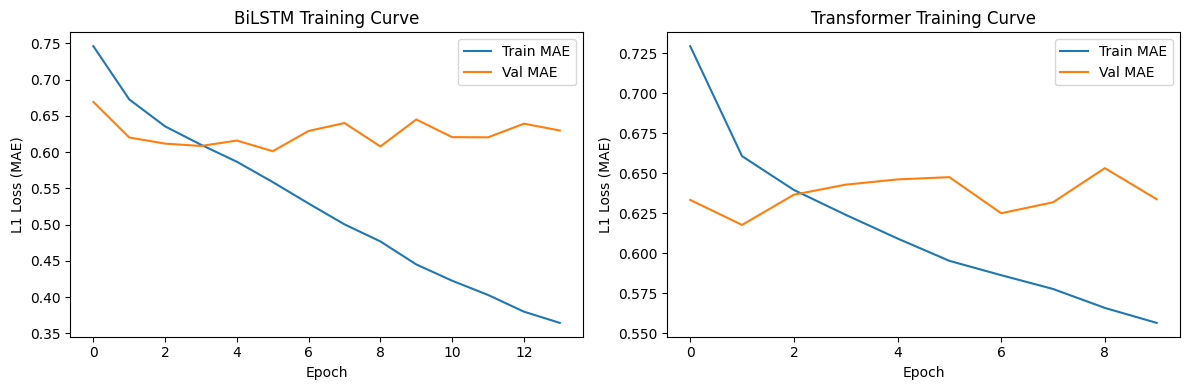

In [35]:
# Training curve for deep models
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, hist_tr, hist_v, title in [
    (axes[0], train_h,   val_h,   "BiLSTM Training Curve"),
    (axes[1], train_h_t, val_h_t, "Transformer Training Curve")
]:
    ax.plot(hist_tr, label='Train MAE')
    ax.plot(hist_v,  label='Val MAE')
    ax.set_xlabel("Epoch")
    ax.set_ylabel("L1 Loss (MAE)")
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.savefig("../figures/08_training_curves.png", bbox_inches='tight')
plt.show()

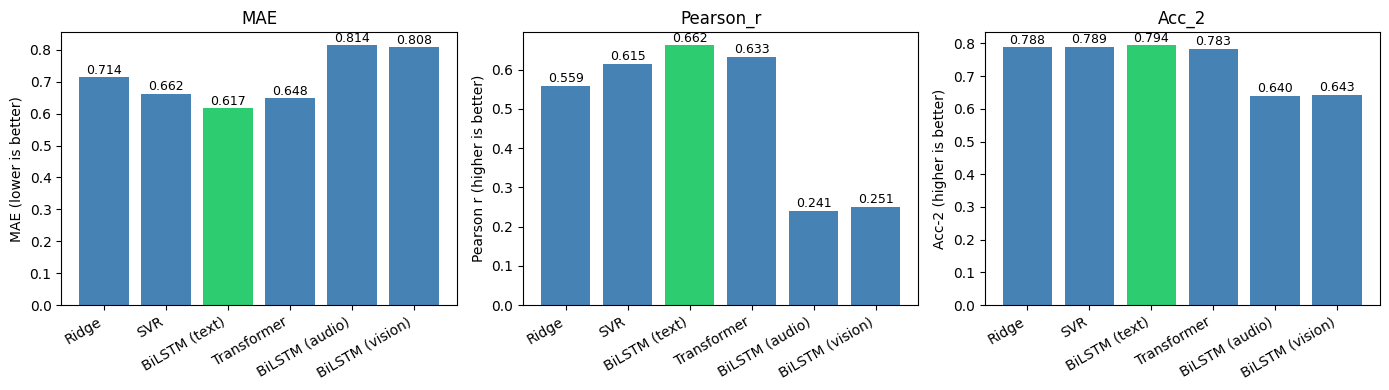

In [41]:
# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

model_names = list(results.keys())

for ax, metric, label, best_fn in [
    (axes[0], "MAE",      "MAE (lower is better)",       min),
    (axes[1], "Pearson_r","Pearson r (higher is better)", max),
    (axes[2], "Acc_2",    "Acc-2 (higher is better)",     max),
]:
    vals = [results[m][metric] for m in model_names]
    best = best_fn(vals)
    colors = ['#2ecc71' if v == best else 'steelblue' for v in vals]

    ax.bar(model_names, vals, color=colors)
    ax.set_ylabel(label)
    ax.set_title(metric)

    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

    for i, v in enumerate(vals):
        ax.text(i, v + 0.002, f"{v:.3f}",
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig("../figures/09_text_model_comparison.png", bbox_inches='tight')
plt.show()

In [37]:
# --- Select best model (lowest MAE on test) ---
best_name = min(results, key=lambda m: results[m]['MAE'])
print(f"Best model: {best_name}  (MAE = {results[best_name]['MAE']:.4f})")

Best model: BiLSTM (text)  (MAE = 0.6170)


## 5. Error Analysis on the Best Model

In [38]:
# --- Get predictions from best deep model ---
# (If best model is Ridge or SVR, use those preds directly)
best_eval = evaluate_model(transformer, testdata)   # change to bilstm if needed
preds_best  = best_eval['preds']
labels_best = best_eval['labels']
errors = np.abs(preds_best - labels_best)

# --- Text lengths on test set ---
lengths_test = []
for batch in testdata:
    text = batch[2].numpy()
    mask = (np.abs(text).sum(-1) > 0)
    lengths_test.extend(mask.sum(-1).tolist())
lengths_test = np.array(lengths_test)

/Users/zhanghanshi/anaconda3/envs/multimodal-env/lib/python3.10/site-packages/torch/nn/modules/transformer.py:562: UserWarning: Converting mask without torch.bool dtype to bool; this will negatively affect performance. Prefer to use a boolean mask directly. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/transformers/attention.cpp:152.)
  return torch._transformer_encoder_layer_fwd(


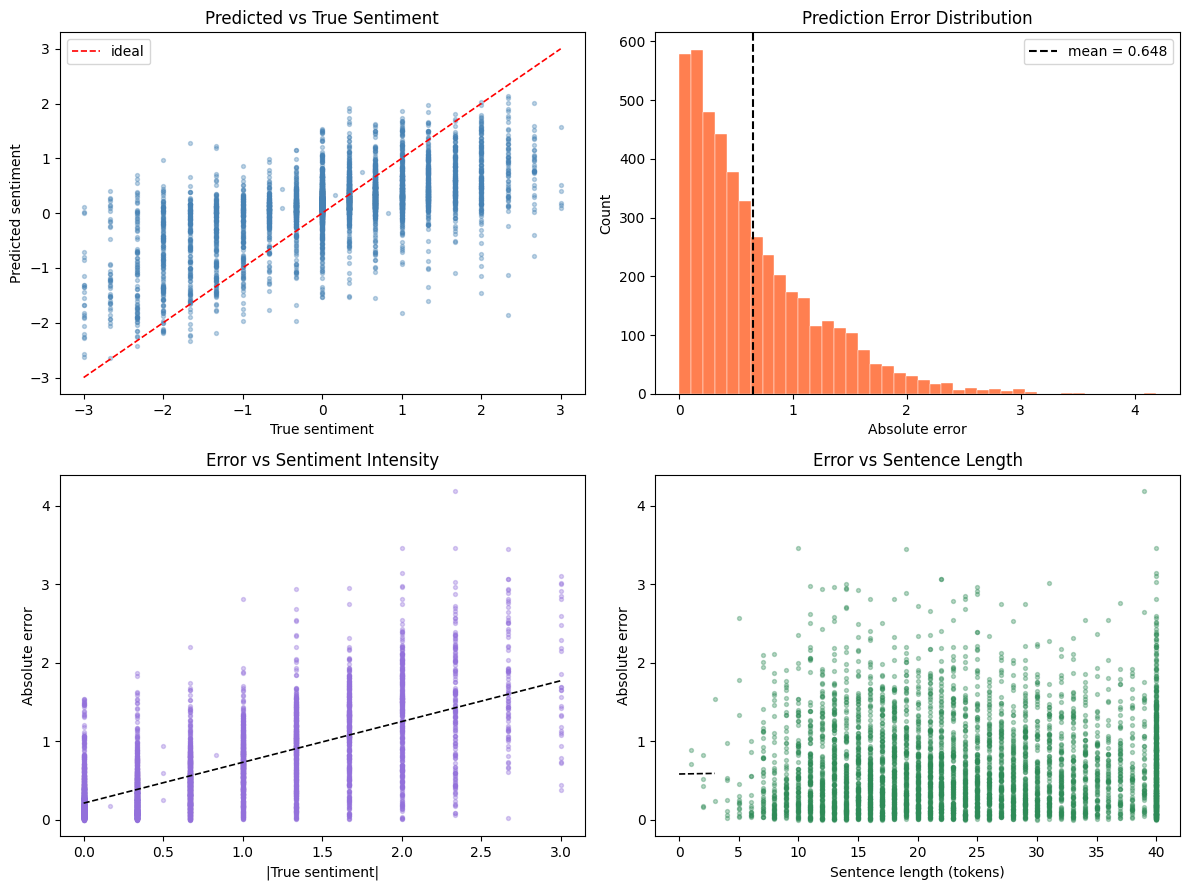

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# 1. True vs predicted
axes[0,0].scatter(labels_best, preds_best, alpha=0.35, s=8, color='steelblue')
axes[0,0].plot([-3, 3], [-3, 3], 'r--', linewidth=1.2, label='ideal')
axes[0,0].set_xlabel("True sentiment")
axes[0,0].set_ylabel("Predicted sentiment")
axes[0,0].set_title("Predicted vs True Sentiment")
axes[0,0].legend()

# 2. Error distribution
axes[0,1].hist(errors, bins=40, color='coral', edgecolor='white', linewidth=0.3)
axes[0,1].axvline(errors.mean(), color='black', linestyle='--',
                   label=f'mean = {errors.mean():.3f}')
axes[0,1].set_xlabel("Absolute error")
axes[0,1].set_ylabel("Count")
axes[0,1].set_title("Prediction Error Distribution")
axes[0,1].legend()

# 3. Error vs sentiment intensity
axes[1,0].scatter(np.abs(labels_best), errors, alpha=0.35, s=8, color='mediumpurple')
m, b = np.polyfit(np.abs(labels_best), errors, 1)
xs = np.linspace(0, 3, 100)
axes[1,0].plot(xs, m*xs + b, 'k--', linewidth=1.2)
axes[1,0].set_xlabel("|True sentiment|")
axes[1,0].set_ylabel("Absolute error")
axes[1,0].set_title("Error vs Sentiment Intensity")

# 4. Error vs sentence length
axes[1,1].scatter(lengths_test[:len(errors)], errors, alpha=0.35, s=8, color='seagreen')
m2, b2 = np.polyfit(lengths_test[:len(errors)], errors, 1)
axes[1,1].plot(xs, m2*xs + b2, 'k--', linewidth=1.2)
axes[1,1].set_xlabel("Sentence length (tokens)")
axes[1,1].set_ylabel("Absolute error")
axes[1,1].set_title("Error vs Sentence Length")

plt.tight_layout()
plt.savefig("../figures/10_error_analysis.png", bbox_inches='tight')
plt.show()

In [40]:
# --- Save all unimodal results for notebook 04 ---
save_data = {}

# Text models
bilstm_full      = evaluate_model(bilstm,      testdata)
transformer_full = evaluate_model(transformer, testdata)
save_data['Ridge']           = {'preds': ridge_preds,               'labels': y_test}
save_data['SVR']             = {'preds': svr_preds,                 'labels': y_test}
save_data['BiLSTM']          = {'preds': bilstm_full['preds'],      'labels': bilstm_full['labels']}
save_data['Transformer']     = {'preds': transformer_full['preds'], 'labels': transformer_full['labels']}

# New: audio and vision unimodal
audio_full  = evaluate_unimodal(audio_bilstm,  testdata, modality_idx=1)
vision_full = evaluate_unimodal(vision_bilstm, testdata, modality_idx=0)
save_data['BiLSTM (audio)']  = {'preds': audio_full['preds'],  'labels': audio_full['labels']}
save_data['BiLSTM (vision)'] = {'preds': vision_full['preds'], 'labels': vision_full['labels']}

# Add scalar metrics to each entry
for name, d in save_data.items():
    d.update({k: v for k, v in compute_metrics(d['preds'], d['labels']).items()
              if k not in ('preds', 'labels')})

with open("../results/text_model_results.pkl", "wb") as f:
    pickle.dump(save_data, f)

print("Saved to ../results/text_model_results.pkl")
print("Keys:", list(save_data.keys()))

/Users/zhanghanshi/anaconda3/envs/multimodal-env/lib/python3.10/site-packages/torch/nn/modules/transformer.py:562: UserWarning: Converting mask without torch.bool dtype to bool; this will negatively affect performance. Prefer to use a boolean mask directly. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/transformers/attention.cpp:152.)
  return torch._transformer_encoder_layer_fwd(


Saved to ../results/text_model_results.pkl
Keys: ['Ridge', 'SVR', 'BiLSTM', 'Transformer', 'BiLSTM (audio)', 'BiLSTM (vision)']


## 6. Limitations of Text-Only Modeling

The error analysis above reveals the following systematic limitations of text-only approaches:

- **Extreme sentiment under-prediction**: errors are larger for samples with high |label|, suggesting that strong emotional content relies on prosodic or facial signals that text alone cannot convey.
- **Short-utterance ambiguity**: very short utterances (≤5 tokens) tend to have higher errors due to insufficient textual context.
- **Neutral-zone clustering**: predicted values cluster near zero more than true labels do, consistent with the model hedging towards the mean for ambiguous inputs.

These observations motivate adding audio and visual modalities in notebook 03.